##### imports

In [41]:
import os
import pandas as pd
import utils as ut
import numpy as np

import importlib as il

# tabnet
from pytorch_tabnet.tab_model import TabNetClassifier

In [42]:
PATH_MODELS = 'F:\\TFG\\code\\framework\\logs\\models\\'

## FEATURE IMPORTANCE in TABNET

In [43]:
il.reload(ut)

<module 'utils' from 'f:\\TFG\\code\\analytics\\utils.py'>

In [44]:
model_name = "tabnet_own_comp_rs_unsup_rps"

In [45]:
model_exp = [ exp for exp in ut.ls_sorted(PATH_MODELS) if model_name in exp][0]
model_name = model_exp.split('\\')[-1]
model_exp

'F:\\TFG\\code\\framework\\logs\\models\\tabnet_own_comp_rs_unsup_rps_202406271926'

In [46]:
os.listdir(f'{PATH_MODELS}{model_name}\\')

['feature_importance_tabnet_own_comp_rs_unsup_rps_202406271926.csv',
 'tabnet_own_comp_rs_unsup_rps_202406271926_v696.zip',
 'test.csv']

In [47]:
clf = TabNetClassifier()

c:\Users\GuillemUPV\Anaconda3\envs\tfg\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


In [48]:
model = [ file for file in os.listdir(f'{PATH_MODELS}{model_name}\\') if file.endswith('.zip')][0]
model

'tabnet_own_comp_rs_unsup_rps_202406271926_v696.zip'

In [49]:
clf.load_model(f'{PATH_MODELS}{model_name}\\{model}')

In [561]:
test = ut.read_data(f'{PATH_MODELS}{model_name}\\test.csv')
features = ut.read_data(f'{PATH_MODELS}{model_name}\\feature_importance_{model_name}.csv').features.to_list()
test

,matchId,Div,Date,season,Weekday,idTeam_H,idTeam_A,HomeTeam,AwayTeam,FTHG,...,Y_180D_H,Y_180D_A,Y_365D_H,Y_365D_A,Y_730D_H,Y_730D_A,Y_1825D_H,Y_1825D_A,_id,split
0,15969,E0,2020-01-01,T19-20,2,52,56,Brighton,Chelsea,1,...,1.400000,1.850000,1.368421,1.552632,1.506667,1.400000,1.479167,1.557895,15969,Val
1,15976,E0,2020-01-01,T19-20,2,88,50,West Ham,Bournemouth,4,...,2.105263,2.050000,1.567568,1.815789,1.680000,1.626667,1.756614,1.505814,15976,Val
2,15975,E0,2020-01-01,T19-20,2,72,58,Norwich,Crystal Palace,1,...,1.900000,1.550000,1.900000,1.447368,1.900000,1.560000,1.706897,1.747368,15975,Val
3,15974,E0,2020-01-01,T19-20,2,68,60,Man City,Everton,2,...,1.950000,1.750000,1.631579,1.631579,1.413333,1.413333,1.610526,1.505263,15974,Val
4,15977,E0,2020-01-01,T19-20,2,43,69,Arsenal,Man United,2,...,2.500000,2.050000,2.210526,1.973684,1.973333,1.893333,1.626316,1.826316,15977,Val
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2626,27047,F1,2021-05-23,T20-21,6,112,118,Lens,Monaco,0,...,2.428571,1.769231,2.459459,2.054054,2.459459,2.121212,2.459459,1.960894,27047,Val
2627,27046,F1,2021-05-23,T20-21,6,101,124,Brest,Paris SG,0,...,1.461538,2.000000,1.648649,2.081081,1.630769,2.015385,1.630769,1.747191,27046,Val
2628,27045,F1,2021-05-23,T20-21,6,95,113,Angers,Lille,1,...,1.384615,1.692308,1.756757,1.783784,1.666667,1.803030,1.603352,1.703911,27045,Val
2629,27049,F1,2021-05-23,T20-21,6,117,116,Metz,Marseille,1,...,2.230769,2.392857,2.162162,2.567568,1.953846,2.515152,1.971631,2.212291,27049,Val


In [562]:
# test = test.sample(n=10,random_state=1)
matches = [6229, 26816, 45513, 26659, 45262,  6034, 45598, 16012, 16379,
       16337, 45482, 35507, 45200, 45602, 35403, 27032, 26609, 16431,
       45550, 35553,  6110, 45492, 35097, 45621, 35105, 27028,  6407,
       26866,  6223, 45530, 35076, 16015, 35132, 45746, 16439,  6265,
       35537, 26838, 35450, 16393, 26831, 16041, 35484, 26827, 16299,
        6067, 26628, 16456, 16480, 26902, 35445, 26996,  6273,  6081,
       26966, 35589, 26644, 16450, 35599, 45664, 45704,  5995, 35519,
       16416,  6386, 35337, 27036, 45477, 16433,  6181, 26926, 35436,
       35488, 16458,  6295, 35544, 16292, 26959, 26967, 16314, 45219,
       45505, 45611, 45708, 26641, 45252, 45228, 26861, 26907, 45625,
       35068, 26634,  6354, 35087, 35581, 45548, 45679, 27020, 26939,
       45506,  6399, 35503, 35605, 35510, 26625, 45526, 15999, 45481,
       45374, 35123, 45567, 45493, 45515, 16030, 35546, 26844, 35525,
       35363, 45193, 35444, 35576, 26636,  6274, 26817, 15976,  6335,
       45752, 35135, 26954, 26807, 45472,  6187, 26905, 45619, 26775,
       26624, 35390,  6266,  6363,  6369, 45218, 45211, 45243, 45573,
       45217, 45613, 45676, 45626, 16000, 45432,  6331, 45678, 35096,
       45731, 26965, 45582, 26662, 35551, 35565, 45207, 45231, 35572,
        6368, 35077, 35453, 26793, 45223, 45734, 16279, 45685, 27033,
       16413, 35381,  6227, 16418, 45561] # partidos --> concat_merged[isRPS & isAcc], concat_merged[isSOTA2] y logits < 0.45
# matches = [6180,  6359,  6056, 16364, 45617, 16344, 16336,  6253, 16372,
#         6229, 16220,  6234, 26816, 16312, 45513, 26659, 35356, 45262,
#         6034, 45598, 35575, 16012, 16379,  6275, 16337, 45482, 35507,
#        45200, 45602, 35403, 27032, 26609,  6310, 16431, 45550, 35553,
#         6110, 26822, 16203, 35097, 45621,  6107, 35105, 27028,  6407,
#        26866,  6223, 16461, 45530, 16015, 35132, 45746,  6330,  6265,
#        35537, 26838, 35450, 16041, 35484, 26628, 35445, 26996,  6273,
#        26966, 16450, 35599,  5995, 16416,  6295, 26967, 45505, 35510,
#        35546, 45752] # partidos --> concat_merged[isRPS & isAcc], concat_merged[isSOTA2 & ~isAcc]

# test = test[test.matchId.isin(matches)].sample(20,random_state=0)
test

,matchId,Div,Date,season,Weekday,idTeam_H,idTeam_A,HomeTeam,AwayTeam,FTHG,...,Y_180D_H,Y_180D_A,Y_365D_H,Y_365D_A,Y_730D_H,Y_730D_A,Y_1825D_H,Y_1825D_A,_id,split
0,15969,E0,2020-01-01,T19-20,2,52,56,Brighton,Chelsea,1,...,1.400000,1.850000,1.368421,1.552632,1.506667,1.400000,1.479167,1.557895,15969,Val
1,15976,E0,2020-01-01,T19-20,2,88,50,West Ham,Bournemouth,4,...,2.105263,2.050000,1.567568,1.815789,1.680000,1.626667,1.756614,1.505814,15976,Val
2,15975,E0,2020-01-01,T19-20,2,72,58,Norwich,Crystal Palace,1,...,1.900000,1.550000,1.900000,1.447368,1.900000,1.560000,1.706897,1.747368,15975,Val
3,15974,E0,2020-01-01,T19-20,2,68,60,Man City,Everton,2,...,1.950000,1.750000,1.631579,1.631579,1.413333,1.413333,1.610526,1.505263,15974,Val
4,15977,E0,2020-01-01,T19-20,2,43,69,Arsenal,Man United,2,...,2.500000,2.050000,2.210526,1.973684,1.973333,1.893333,1.626316,1.826316,15977,Val
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2626,27047,F1,2021-05-23,T20-21,6,112,118,Lens,Monaco,0,...,2.428571,1.769231,2.459459,2.054054,2.459459,2.121212,2.459459,1.960894,27047,Val
2627,27046,F1,2021-05-23,T20-21,6,101,124,Brest,Paris SG,0,...,1.461538,2.000000,1.648649,2.081081,1.630769,2.015385,1.630769,1.747191,27046,Val
2628,27045,F1,2021-05-23,T20-21,6,95,113,Angers,Lille,1,...,1.384615,1.692308,1.756757,1.783784,1.666667,1.803030,1.603352,1.703911,27045,Val
2629,27049,F1,2021-05-23,T20-21,6,117,116,Metz,Marseille,1,...,2.230769,2.392857,2.162162,2.567568,1.953846,2.515152,1.971631,2.212291,27049,Val


In [563]:
logits_sota = ut.read_data('F:\TFG\code\\framework\logs\mobaxterm\\experiments_v2.2\\lgbm_top1_rs_logits.csv')
test = test[test.Div!='SP2'][test.matchId.isin(logits_sota.match)].sample(20,random_state=0)
logits_sota = logits_sota[logits_sota.match.isin(test.matchId.to_list())]
logits_sota = logits_sota[['draw','home','away']].values

<ipython-input-563-26ac529f1176>:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  test = test[test.Div!='SP2'][test.matchId.isin(logits_sota.match)].sample(20,random_state=0)


In [564]:
order_feats = [ feat for feat in test.columns if feat in features]
input_test = test[order_feats].values
input_test.shape

(20, 140)

In [565]:
logits = clf.predict_proba(input_test)
preds = logits.argmax(axis=1)
accuracy = (preds==test.label.values).mean()
accuracy

0.55

In [566]:
explain_matrix, masks = clf.explain(input_test)

In [567]:
explain_matrix.shape

(20, 140)

In [568]:
test_str = test['Date'].astype(str) + ': ' + test['HomeTeam'] + ' vs ' + test['AwayTeam'] + ' --> ' + test['FTHG'].astype(str) + '-' + test['FTAG'].astype(str)
test_str.values

array(['2021-04-11: Monaco vs Dijon --> 3-0',
       '2021-03-13: Mainz vs Freiburg --> 1-0',
       '2021-01-16: Marseille vs Nimes --> 1-2',
       '2021-05-23: Sevilla vs Alaves --> 1-0',
       '2021-02-14: Levante vs Osasuna --> 0-1',
       '2020-02-15: Nantes vs Metz --> 0-0',
       '2021-01-19: Cadiz vs Levante --> 2-2',
       '2020-02-02: FC Koln vs Freiburg --> 4-0',
       '2021-05-08: Alaves vs Levante --> 2-2',
       '2020-02-08: Ath Madrid vs Granada --> 1-0',
       '2021-05-01: Paris SG vs Lens --> 2-1',
       '2020-02-01: Dijon vs Brest --> 3-0',
       '2021-02-14: Everton vs Fulham --> 0-2',
       '2020-11-29: Napoli vs Roma --> 4-0',
       '2021-03-03: St Etienne vs Lens --> 2-3',
       '2021-04-29: Barcelona vs Granada --> 1-2',
       '2020-02-09: Betis vs Barcelona --> 2-3',
       '2020-11-22: Inter vs Torino --> 4-2',
       '2021-04-24: West Ham vs Chelsea --> 0-1',
       '2021-05-08: Werder Bremen vs Leverkusen --> 0-0'], dtype=object)

In [569]:
explain_matrix

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

<ipython-input-570-6dd55a815fd1>:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[i][j].set_xticklabels(col_values, rotation=45)


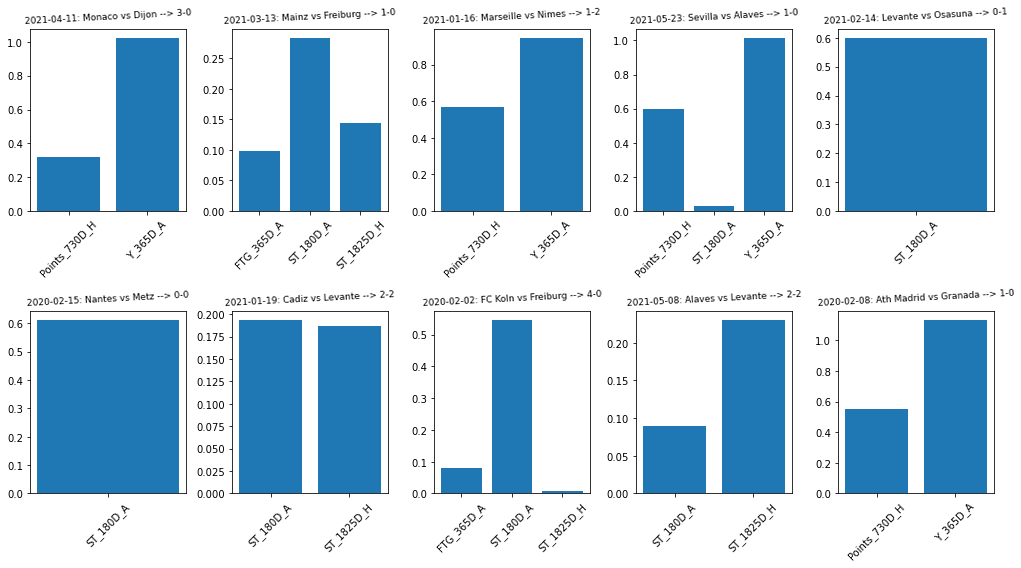

In [570]:
df_plot = explain_matrix[:10]  # Debe ser una matriz numpy
n = len(df_plot)
cols = 5
rows = int((n / cols) + 1) if n%cols>0 else int(n / cols)
fig, axs = plt.subplots(rows, cols, figsize=(14, 8))

for i in range(rows):
    for j in range(cols):
        k = cols * i + j
        if k + 1 > n:
            break
        idxs = np.where(explain_matrix[k] > 0)[0]
        col_values = np.take(order_feats, idxs)
        axs[i][j].bar(col_values, df_plot[k][idxs])
        axs[i][j].set_xticklabels(col_values, rotation=45)
        axs[i][j].set_title(test_str.values[k], fontsize=9, rotation=3)

plt.tight_layout()
# plt.savefig('F:\\TFG\\conference\\graphs\\v2\\'+'feat_imp_matches'+'.jpeg', bbox_inches='tight', dpi='figure')
plt.show()


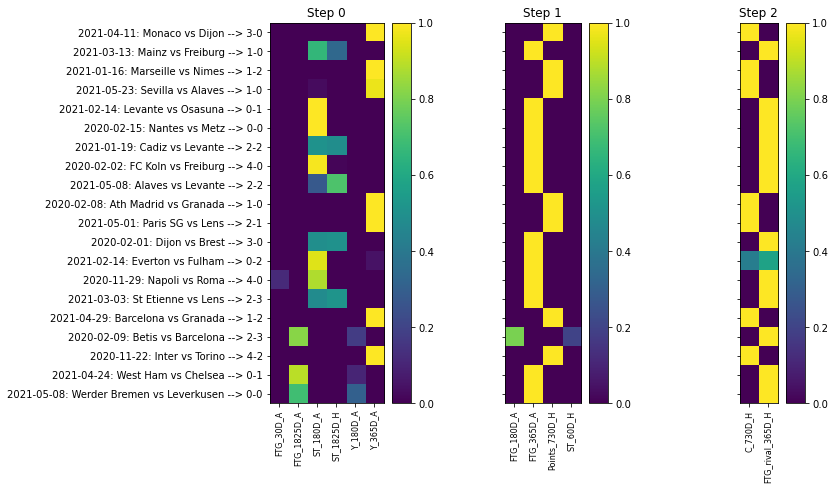

In [571]:
from matplotlib import pyplot as plt
from functools import reduce


fig, axs = plt.subplots(1,3, figsize=(10,7))
vmin, vmax = 0,1
for i in range(3):
    mask_df = pd.DataFrame(masks[i])
    topcols = np.where((mask_df.sum()>0).values)[0]
    ca = axs[i].imshow(mask_df[topcols], vmin=vmin, vmax=vmax)
    axs[i].set_xticks(range(len(topcols)))
    axs[i].set_xticklabels(np.take(order_feats,topcols), rotation=90, fontsize=8)
    axs[i].set_yticks(range(len(test_str.values)))
    if i== 0: axs[i].set_yticklabels(test_str.values, rotation=0)
    else: axs[i].set_yticklabels([])
    axs[i].set_title(f"Step {i}")
    fig.colorbar(ca, ax=axs[i])
    
plt.savefig('F:\\TFG\\conference\\graphs\\v2\\'+'feat_imp_matches_classes_random'+'.jpeg', bbox_inches='tight', dpi='figure')

0.034915682 0.86538553
0.0728 0.815


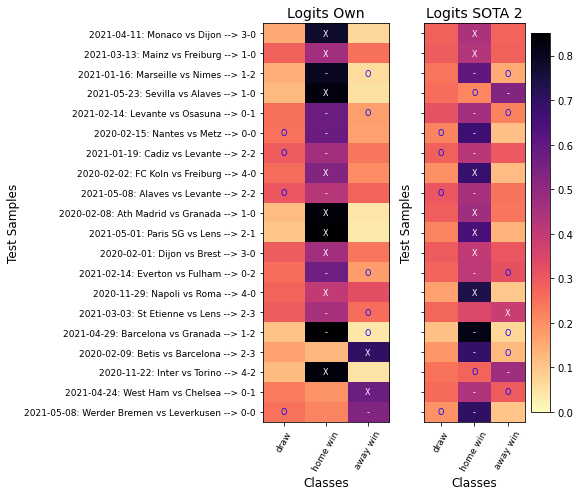

In [572]:
def add_numbers_to_heatmap(matrix, ax, color_func=lambda v: 'blue' if v<0.34 else 'white'):
    for i in range(matrix.shape[0]):
            if test.iloc[i].label!=matrix[i].argmax():
                text = ax.text(test.iloc[i].label, i, 'O',
                           ha='center', va='center', color=color_func(matrix[i, test.iloc[i].label]), fontsize=8)
                text = ax.text(matrix[i].argmax(), i, '-',
                                ha='center', va='center', color=color_func(matrix[i, matrix[i].argmax()]), fontsize=8)
            else:
                text = ax.text(matrix[i].argmax(), i, 'X',
                                ha='center', va='center', color=color_func(matrix[i, matrix[i].argmax()]), fontsize=8)
# Create a larger figure
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(8, 7))  # Increase the figsize for a larger plot

# Display the heatmap
print(logits.min(),logits.max())
print(logits_sota.min(),logits_sota.max())
cax = ax1.imshow(logits, cmap='magma_r', aspect='auto', vmin=0, vmax=0.85)
add_numbers_to_heatmap(logits, ax1)
# Set x-ticks and y-ticks with appropriate labels and font sizes
ax1.set_xticks(range(3))
ax1.set_xticklabels(['draw','home win','away win'], rotation=60, fontsize=9)
ax1.set_yticks(range(len(test_str)))
ax1.set_yticklabels(test_str, rotation=0, fontsize=9)
# Set labels and title for better context (optional)
ax1.set_xlabel('Classes', fontsize=12)
ax1.set_ylabel('Test Samples', fontsize=12)
ax1.set_title('Logits Own', fontsize=14)

cax = ax2.imshow(logits_sota, cmap='magma_r', aspect='auto', vmin=0, vmax=0.85)
add_numbers_to_heatmap(logits_sota, ax2)
# Set x-ticks and y-ticks with appropriate labels and font sizes
ax2.set_xticks(range(3))
ax2.set_xticklabels(['draw','home win','away win'], rotation=60, fontsize=9)
ax2.set_yticks(range(len(test_str)))
ax2.set_yticklabels([])
# Set labels and title for better context (optional)
ax2.set_xlabel('Classes', fontsize=12)
ax2.set_ylabel('Test Samples', fontsize=12)
ax2.set_title('Logits SOTA 2', fontsize=14)

# Add a colorbar
fig.colorbar(cax, ax=ax2)
# Adjust layout to prevent overlap
plt.tight_layout()

# Save the figure (optional)
plt.savefig('F:\\TFG\\conference\\graphs\\v2\\'+'feat_imp_matches_classes_logits_random.jpeg', bbox_inches='tight', dpi='figure')

# Show the plot
plt.show()

,match,Date,season,Div,HomeTeam,AwayTeam,FTHG,FTAG,label,prediction,draw,home,away
0,15969,2020-01-01,T19-20,E0,Brighton,Chelsea,1,1,0.0,2,0.2546,0.2463,0.4991
1,15971,2020-01-01,T19-20,E0,Newcastle,Leicester,0,3,2.0,2,0.2754,0.3252,0.3994
2,15972,2020-01-01,T19-20,E0,Southampton,Tottenham,1,0,1.0,2,0.2548,0.2323,0.5129
3,15973,2020-01-01,T19-20,E0,Watford,Wolves,2,1,1.0,1,0.2771,0.3696,0.3533
4,15974,2020-01-01,T19-20,E0,Man City,Everton,2,1,1.0,1,0.1597,0.7361,0.1042
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2404,27052,2021-05-23,T20-21,F1,Rennes,Nimes,2,0,1.0,1,0.2538,0.5494,0.1968
2405,27053,2021-05-23,T20-21,F1,St Etienne,Dijon,0,1,2.0,1,0.2467,0.5477,0.2056
2406,27054,2021-05-23,T20-21,F1,Strasbourg,Lorient,1,1,0.0,1,0.2711,0.4619,0.2670
2407,45755,2021-05-23,T20-21,SP1,Granada,Getafe,0,0,0.0,1,0.2875,0.4388,0.2738


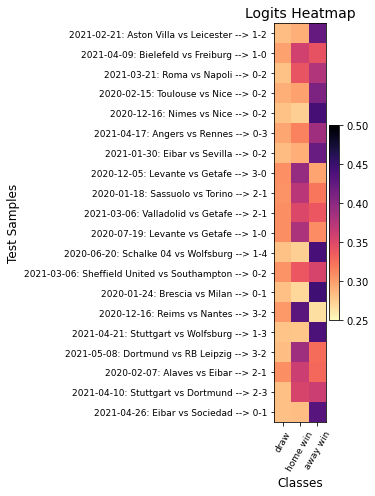

In [399]:
# Create a larger figure
fig, ax = plt.subplots(figsize=(5, 7))  # Increase the figsize for a larger plot

# Display the heatmap
cax = ax.imshow(logits, cmap='magma_r', aspect='auto', vmin=0.25, vmax=0.5)

# Set x-ticks and y-ticks with appropriate labels and font sizes
ax.set_xticks(range(3))
ax.set_xticklabels(['draw','home win','away win'], rotation=60, fontsize=9)
ax.set_yticks(range(len(test_str)))
ax.set_yticklabels(test_str, rotation=0, fontsize=9)

# Add a colorbar
fig.colorbar(cax, ax=ax)

# Set labels and title for better context (optional)
ax.set_xlabel('Classes', fontsize=12)
ax.set_ylabel('Test Samples', fontsize=12)
ax.set_title('Logits Heatmap', fontsize=14)

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the figure (optional)
plt.savefig('F:\\TFG\\conference\\graphs\\v2\\'+'feat_imp_matches_classes_logits.jpeg', bbox_inches='tight', dpi='figure')

# Show the plot
plt.show()

In [ ]:
from matplotlib import pyplot as plt
from functools import reduce


fig, axs = plt.subplots(1,3, figsize=(10,7))
vmin, vmax = 0,1
for i in range(3):
    mask_df = pd.DataFrame(logits)
    topcols = np.where((mask_df.sum()>0).values)[0]
    ca = axs[i].imshow(mask_df[topcols], vmin=vmin, vmax=vmax)
    axs[i].set_xticks(range(len(topcols)))
    axs[i].set_xticklabels(np.take(order_feats,topcols), rotation=90, fontsize=8)
    axs[i].set_yticks(range(len(test_str.values)))
    if i== 0: axs[i].set_yticklabels(test_str.values, rotation=0)
    else: axs[i].set_yticklabels([])
    axs[i].set_title(f"Step {i}")
    fig.colorbar(ca, ax=axs[i])
    
# plt.savefig('F:\\TFG\\conference\\graphs\\v2\\'+'feat_imp_matches_classes_bothacc'+'.jpeg', bbox_inches='tight', dpi='figure')

#### Nivel modelo

In [22]:

ls_logs = os.listdir(ut.PATH_LOGS)
experiments = ut.filter_list(r'(tabnet_\w+)_logits.csv',','.join(ls_logs))
experiments

['tabnet_owntop1_adv_comp_ss_sup',
 'tabnet_owntop1_comp_ss_sup',
 'tabnet_own_comp_rs_unsup',
 'tabnet_own_comp_ss_sup',
 'tabnet_own_simp_ss_sup',
 'tabnet_own_simp_ss_unsup',
 'tabnet_paper_ss_unsup']

In [23]:
PATH_FEAT_IMPORTANCE = f"F:\TFG\code\\framework\logs\models\\"

In [27]:
def ls_sorted(search_dir:str):
    os.chdir(search_dir)
    files = filter(os.path.isdir, os.listdir(search_dir))
    files = [os.path.join(search_dir, f) for f in files] # add path to each file
    files.sort(key=lambda x: os.path.getmtime(x),reverse=True)
    return files

In [28]:
ls_feat_imp = ls_sorted(PATH_FEAT_IMPORTANCE)
ls_feat_imp

['F:\\TFG\\code\\framework\\logs\\models\\tabnet_paper_rs_unsup_202406100925',
 'F:\\TFG\\code\\framework\\logs\\models\\tabnet_own_simp_ss_unsup_202406122130',
 'F:\\TFG\\code\\framework\\logs\\models\\tabnet_owntop1_comp_ss_sup_202406150937',
 'F:\\TFG\\code\\framework\\logs\\models\\tabnet_paper_ss_unsup_202406172147',
 'F:\\TFG\\code\\framework\\logs\\models\\tabnet_owntop1_adv_comp_ss_sup_202406072117',
 'F:\\TFG\\code\\framework\\logs\\models\\own_original_simp_fac_ss_202405201113',
 'F:\\TFG\\code\\framework\\logs\\models\\lgbm_top1_ss_202405211459',
 'F:\\TFG\\code\\framework\\logs\\models\\own_top1_comp_fac_ss_202405211459',
 'F:\\TFG\\code\\framework\\logs\\models\\tabnet_own_comp_ss_sup_202405232005',
 'F:\\TFG\\code\\framework\\logs\\models\\own_top1_adv_comp_fac_ss_202405240417',
 'F:\\TFG\\code\\framework\\logs\\models\\lgbm_top1_rs_202405261535',
 'F:\\TFG\\code\\framework\\logs\\models\\tabnet_own_simp_ss_sup_202405260830',
 'F:\\TFG\\code\\framework\\logs\\models\\tabn

In [30]:
feats_paths = []
for exp in experiments:
    list_paths = [ path for path in ls_feat_imp if exp in path]
    if len(list_paths)>0:
        feats_paths.append(list_paths[0])
    else:
        print(exp)

feats_paths

['F:\\TFG\\code\\framework\\logs\\models\\tabnet_owntop1_adv_comp_ss_sup_202406072117',
 'F:\\TFG\\code\\framework\\logs\\models\\tabnet_owntop1_comp_ss_sup_202406150937',
 'F:\\TFG\\code\\framework\\logs\\models\\tabnet_own_comp_rs_unsup_202405310904',
 'F:\\TFG\\code\\framework\\logs\\models\\tabnet_own_comp_ss_sup_202405232005',
 'F:\\TFG\\code\\framework\\logs\\models\\tabnet_own_simp_ss_sup_202405260830',
 'F:\\TFG\\code\\framework\\logs\\models\\tabnet_own_simp_ss_unsup_202406122130',
 'F:\\TFG\\code\\framework\\logs\\models\\tabnet_paper_ss_unsup_202406172147']

In [56]:
il.reload(ut)

names_feats = [ path.split('\\')[-1] for path in feats_paths ]
names_feats

['tabnet_owntop1_adv_comp_ss_sup_202406072117',
 'tabnet_owntop1_comp_ss_sup_202406150937',
 'tabnet_own_comp_rs_unsup_202405310904',
 'tabnet_own_comp_ss_sup_202405232005',
 'tabnet_own_simp_ss_sup_202405260830',
 'tabnet_own_simp_ss_unsup_202406122130',
 'tabnet_paper_ss_unsup_202406172147']

In [107]:
dict_feats = {}
for name,path in zip(names_feats,feats_paths):
    df_feats = pd.read_csv(f'{path}\\feature_importance_{name}.csv',sep=';',decimal=',')
    df_feats = df_feats.rename(columns={'importance':name})
    df_feats.set_index('features',inplace=True)
    dict_feats[name] = df_feats

len(dict_feats)

7

In [108]:
df_concat = pd.concat(dict_feats.values(),axis=1,join='outer')
df_concat

,tabnet_owntop1_adv_comp_ss_sup_202406072117,tabnet_owntop1_comp_ss_sup_202406150937,tabnet_own_comp_rs_unsup_202405310904,tabnet_own_comp_ss_sup_202405232005,tabnet_own_simp_ss_sup_202405260830,tabnet_own_simp_ss_unsup_202406122130,tabnet_paper_ss_unsup_202406172147
features,,,,,,,
top6_A,0.162975,NaN,NaN,NaN,NaN,NaN,NaN
Points_365D_H,0.086121,0.000427,0.222533,0.051854,0.176730,0.157011,NaN
S_365D_A,0.075580,0.000000,0.000000,0.000017,NaN,NaN,NaN
Side_15D_A,0.064530,0.000000,0.000000,0.002820,0.004076,0.000000,NaN
pagerank_10_H,0.056963,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
rounds,0.000000,0.000003,NaN,NaN,NaN,NaN,NaN
pagerank_A,NaN,0.022808,NaN,NaN,NaN,NaN,NaN
pagerank_H,NaN,0.005004,NaN,NaN,NaN,NaN,NaN


In [105]:
df_concat.loc[:,'COUNT'] = df_concat[names_feats].count(axis=1)
df_concat.loc[:,'MEAN'] = df_concat[names_feats].mean(axis=1)
df_concat = df_concat.sort_values('MEAN',ascending=False)
df_concat

,tabnet_owntop1_adv_comp_ss_sup_202406072117,tabnet_owntop1_comp_ss_sup_202406150937,tabnet_own_comp_rs_unsup_202405310904,tabnet_own_comp_ss_sup_202405232005,tabnet_own_simp_ss_sup_202405260830,tabnet_own_simp_ss_unsup_202406122130,tabnet_paper_ss_unsup_202406172147,COUNT,MEAN
features,,,,,,,,,
rate_away,0.040910,0.000071,NaN,NaN,NaN,NaN,0.578033,3,0.206338
top6_A,0.162975,NaN,NaN,NaN,NaN,NaN,NaN,1,0.162975
rate_home,0.000000,0.030108,NaN,NaN,NaN,NaN,0.421967,3,0.150692
Points_365D_H,0.086121,0.000427,0.222533,0.051854,0.176730,0.157011,NaN,6,0.115779
Points_1825D_A,0.028533,0.052578,0.180427,0.053740,0.139459,0.000000,NaN,6,0.075789
...,...,...,...,...,...,...,...,...,...
R_60D_H,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,4,0.000000
S_730D_H,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,4,0.000000
R_730D_A,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,4,0.000000


In [106]:
df_concat.reset_index().to_csv('F:\\TFG\\code\\framework\\logs\\'+'feat_importance_v2.2.csv',sep=';',decimal=',')